In [248]:
import pandas as pd

In [249]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

In [250]:
datos= pd.read_json(url)

In [251]:
datos = pd.json_normalize(datos.to_dict(orient='records'))

In [252]:
datos.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [253]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [254]:
datos.columns = [col.split('.')[-1] for col in datos.columns]

datos['Total'] = pd.to_numeric(datos['Total'], errors='coerce')

datos.dropna(subset=['Total'], inplace=True)

datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [255]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             7256 non-null   object 
 2   gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   object 
 5   Dependents        7256 non-null   object 
 6   tenure            7256 non-null   int64  
 7   PhoneService      7256 non-null   object 
 8   MultipleLines     7256 non-null   object 
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    7256 non-null   object 
 11  OnlineBackup      7256 non-null   object 
 12  DeviceProtection  7256 non-null   object 
 13  TechSupport       7256 non-null   object 
 14  StreamingTV       7256 non-null   object 
 15  StreamingMovies   7256 non-null   object 
 16  Contract          7256 non-null   object 
 17  

In [256]:
print("--- Valores Ausentes ---")
print(datos.isnull().sum())

print("\n--- Filas Duplicadas ---")
print(f"Cantidad de duplicados: {datos.duplicated().sum()}")

print("\n--- Valores únicos en columnas clave ---")
columnas_criticas = ['Churn', 'InternetService', 'Contract', 'PaymentMethod']
for col in columnas_criticas:
    print(f"{col}: {datos[col].unique()}")

espacios_vacios = (datos['Total'] == " ").sum()
print(f"\nEspacios vacíos detectados en 'Total': {espacios_vacios}")

--- Valores Ausentes ---
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Monthly             0
Total               0
dtype: int64

--- Filas Duplicadas ---
Cantidad de duplicados: 0

--- Valores únicos en columnas clave ---
Churn: ['No' 'Yes' '']
InternetService: ['DSL' 'Fiber optic' 'No']
Contract: ['One year' 'Month-to-month' 'Two year']
PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

Espacios vacíos detectados en 'Total': 0


In [257]:
datos['Total'] = pd.to_numeric(datos['Total'], errors='coerce')

import numpy as np
datos['Churn'] = datos['Churn'].replace(' ', np.nan)
datos.dropna(subset=['Churn'], inplace=True)

datos.dropna(subset=['Total'], inplace=True)

datos.replace('No internet service', 'No', inplace=True)
datos.replace('No phone service', 'No', inplace=True)

datos.drop_duplicates(inplace=True)

print("¡Limpieza completada!")
print(f"Filas finales: {len(datos)}")

¡Limpieza completada!
Filas finales: 7256


In [258]:
# 1. Convertimos 'Total' a número (esto genera NaNs donde había espacios)
datos['Total'] = pd.to_numeric(datos['Total'], errors='coerce')

# 2. Eliminamos filas donde 'Total' sea NaN (acá se van los 11 que mencionamos)
datos = datos.dropna(subset=['Total'])

# 3. Limpiamos la columna Churn de cualquier espacio invisible y borramos los vacíos
datos = datos[datos['Churn'].str.strip() != ""]

# 4. Verificamos el contador final
print(f"Filas finales reales: {len(datos)}")

Filas finales reales: 7032


In [259]:
datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [260]:
print("--- Revisión de Categorías ---")
for col in datos.select_dtypes(include='object').columns:
    if col != 'customerID':
        print(f"{col}: {datos[col].unique()}")

datos.replace('No internet service', 'No', inplace=True)
datos.replace('No phone service', 'No', inplace=True)

print(f"\nDuplicados finales: {datos.duplicated().sum()}")

print("\n--- Tipos de datos listos ---")
print(datos.dtypes)

--- Revisión de Categorías ---
Churn: ['No' 'Yes']
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['Yes' 'No']
PhoneService: ['Yes' 'No']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['Yes' 'No']
StreamingTV: ['Yes' 'No']
StreamingMovies: ['No' 'Yes']
Contract: ['One year' 'Month-to-month' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

Duplicados finales: 0

--- Tipos de datos listos ---
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
Te

In [261]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             7032 non-null   object 
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   object 
 5   Dependents        7032 non-null   object 
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   object 
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   object 
 11  OnlineBackup      7032 non-null   object 
 12  DeviceProtection  7032 non-null   object 
 13  TechSupport       7032 non-null   object 
 14  StreamingTV       7032 non-null   object 
 15  StreamingMovies   7032 non-null   object 
 16  Contract          7032 non-null   object 
 17  

In [262]:
for col in datos.select_dtypes(include='object').columns:
    if col != 'customerID':
        datos[col] = datos[col].str.strip().str.lower()

datos.replace(['no internet service', 'no phone service'], 'no', inplace=True)

for col in datos.select_dtypes(include='object').columns:
    if col != 'customerID':
        datos[col] = datos[col].str.capitalize()

print("--- Categorías Corregidas y Coherentes ---")
for col in ['Churn', 'InternetService', 'Contract']:
    print(f"{col}: {datos[col].unique()}")

print(f"\nTotal de registros coherentes: {len(datos)}")

--- Categorías Corregidas y Coherentes ---
Churn: ['No' 'Yes']
InternetService: ['Dsl' 'Fiber optic' 'No']
Contract: ['One year' 'Month-to-month' 'Two year']

Total de registros coherentes: 7032


In [263]:
datos['Cuentas_Diarias'] = (datos['Monthly'] / 30).round(2)

print(datos[['Monthly', 'Cuentas_Diarias']].head())

print("\nEstadísticas de Cuentas Diarias:")
print(datos['Cuentas_Diarias'].describe())

   Monthly  Cuentas_Diarias
0     65.6             2.19
1     59.9             2.00
2     73.9             2.46
3     98.0             3.27
4     83.9             2.80

Estadísticas de Cuentas Diarias:
count    7032.000000
mean        2.159891
std         1.002955
min         0.610000
25%         1.187500
50%         2.340000
75%         2.992500
max         3.960000
Name: Cuentas_Diarias, dtype: float64


In [264]:
datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,Dsl,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,Dsl,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [265]:
import numpy as np

datos['Cuentas_Diarias'] = (datos['Monthly'] / 30).round(2)

columnas_es = {
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono',
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'Socio',
    'Dependents': 'Dependientes',
    'tenure': 'Meses_Permanencia',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Lineas_Multiples',
    'InternetService': 'Servicio_Internet',
    'OnlineSecurity': 'Seguridad_Online',
    'OnlineBackup': 'Respaldo_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Peliculas',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Facturacion_Electronica',
    'PaymentMethod': 'Metodo_Pago',
    'Monthly': 'Cargos_Mensuales',
    'Total': 'Cargos_Totales'
}
datos.rename(columns=columnas_es, inplace=True)

datos.replace({'Yes': 'Si', 'No': 'No'}, inplace=True)

for col in datos.select_dtypes(include='object').columns:
    if col != 'ID_Cliente':
        datos[col] = datos[col].astype(str).str.capitalize()

In [266]:
datos.head()

,ID_Cliente,Abandono,Genero,Adulto_Mayor,Socio,Dependientes,Meses_Permanencia,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Si,Si,9,Si,No,Dsl,...,No,Si,Si,No,One year,Si,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Si,Si,Dsl,...,No,No,No,Si,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Si,Male,0,No,No,4,Si,No,Fiber optic,...,Si,No,No,No,Month-to-month,Si,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Si,Male,1,Si,No,13,Si,No,Fiber optic,...,Si,No,Si,Si,Month-to-month,Si,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Si,Female,1,Si,No,3,Si,No,Fiber optic,...,No,Si,Si,No,Month-to-month,Si,Mailed check,83.9,267.40,2.80


In [267]:
print("--- Métricas de Variables Numéricas ---")
print(datos[['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']].describe())

print("\n--- Distribución de Abandono (Churn) ---")
print(datos['Abandono'].value_counts(normalize=True) * 100)

print("\n--- Resumen de Categorías Principales ---")
print(datos[['Contrato', 'Servicio_Internet', 'Metodo_Pago']].describe(include='all'))

--- Métricas de Variables Numéricas ---
       Meses_Permanencia  Cargos_Mensuales  Cargos_Totales  Cuentas_Diarias
count        7032.000000       7032.000000     7032.000000      7032.000000
mean           32.421786         64.798208     2283.300441         2.159891
std            24.545260         30.085974     2266.771362         1.002955
min             1.000000         18.250000       18.800000         0.610000
25%             9.000000         35.587500      401.450000         1.187500
50%            29.000000         70.350000     1397.475000         2.340000
75%            55.000000         89.862500     3794.737500         2.992500
max            72.000000        118.750000     8684.800000         3.960000

--- Distribución de Abandono (Churn) ---
Abandono
No    73.421502
Si    26.578498
Name: proportion, dtype: float64

--- Resumen de Categorías Principales ---
              Contrato Servicio_Internet       Metodo_Pago
count             7032              7032              7032

In [268]:
print("--- Promedios según Abandono ---")
resumen_comparativo = datos.groupby('Abandono')[['Meses_Permanencia', 'Cargos_Mensuales', 'Cuentas_Diarias']].mean()
print(resumen_comparativo)

print("\n--- Contrato vs Abandono (Frecuencia) ---")
print(pd.crosstab(datos['Contrato'], datos['Abandono'], normalize='index') * 100)

--- Promedios según Abandono ---
          Meses_Permanencia  Cargos_Mensuales  Cuentas_Diarias
Abandono                                                      
No                37.650010         61.307408         2.043486
Si                17.979133         74.441332         2.481450

--- Contrato vs Abandono (Frecuencia) ---
Abandono               No         Si
Contrato                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


/tmp/ipykernel_7787/107227731.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Abandono', data=datos, palette='viridis')


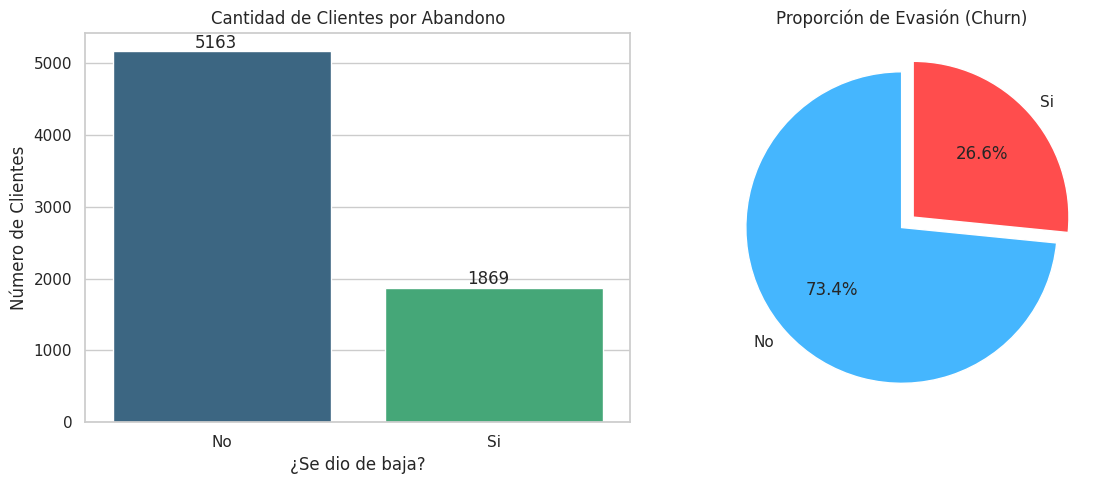

In [269]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ax = sns.countplot(x='Abandono', data=datos, palette='viridis')
plt.title('Cantidad de Clientes por Abandono')
plt.xlabel('¿Se dio de baja?')
plt.ylabel('Número de Clientes')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 50))

plt.subplot(1, 2, 2)
datos['Abandono'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#45b6fe', '#ff4d4d'], explode=(0, 0.1))
plt.title('Proporción de Evasión (Churn)')
plt.ylabel('')

plt.tight_layout()
plt.show()

/tmp/ipykernel_7787/3265664160.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Abandono', data=datos, palette='viridis')


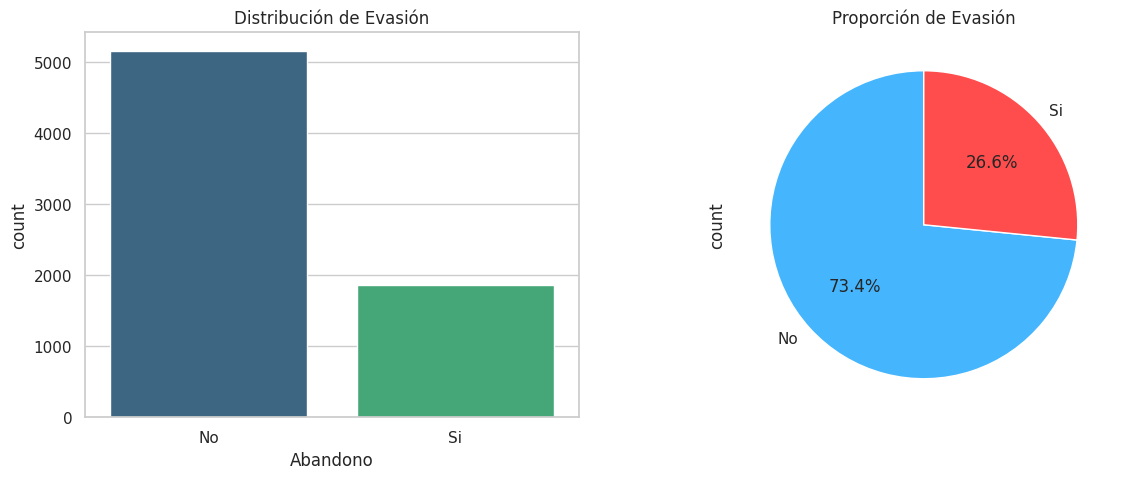

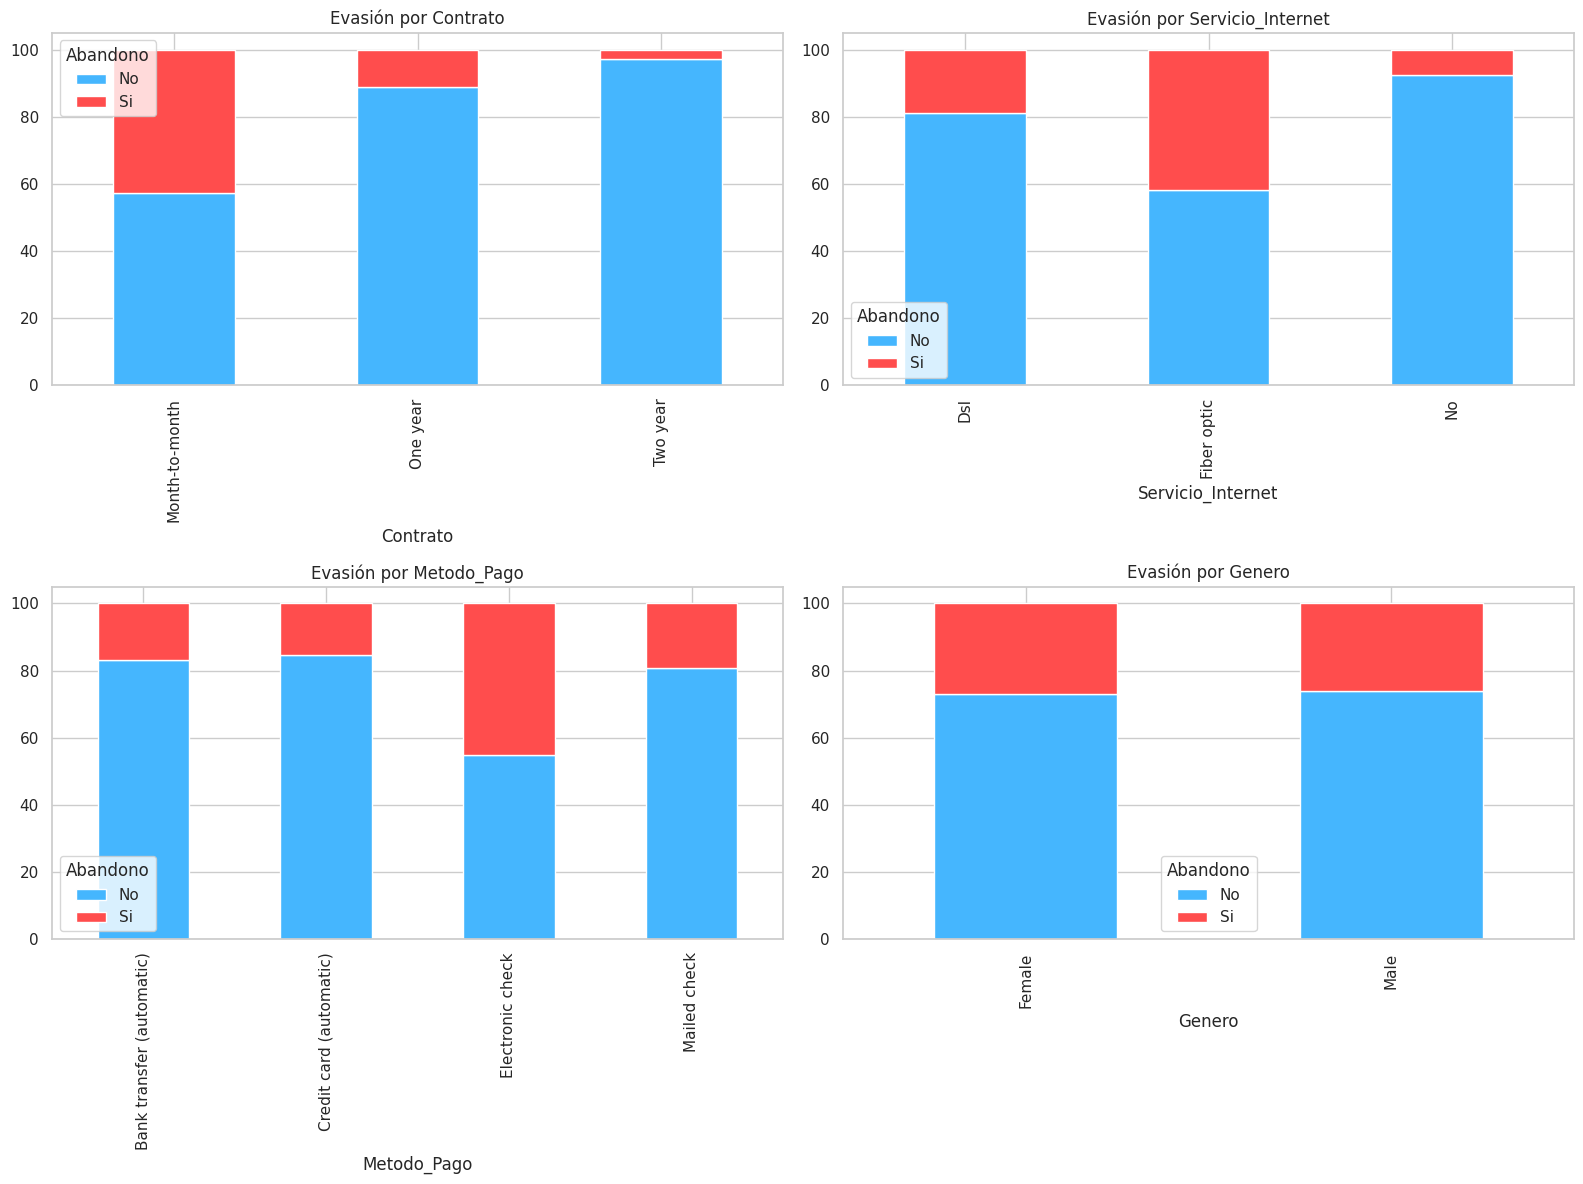

/tmp/ipykernel_7787/3265664160.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y=col, data=datos, ax=axes[i], palette='magma')
/tmp/ipykernel_7787/3265664160.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y=col, data=datos, ax=axes[i], palette='magma')
/tmp/ipykernel_7787/3265664160.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y=col, data=datos, ax=axes[i], palette='magma')


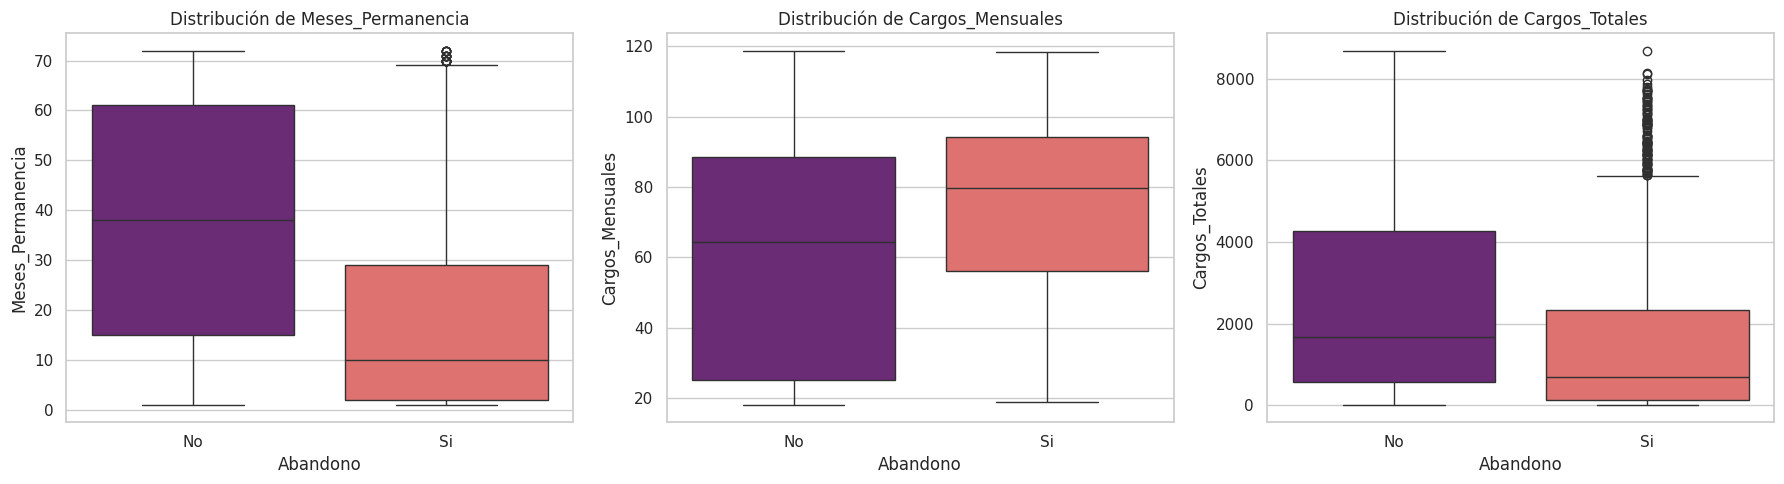

In [270]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='Abandono', data=datos, palette='viridis')
plt.title('Distribución de Evasión')
plt.subplot(1, 2, 2)
datos['Abandono'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#45b6fe', '#ff4d4d'], startangle=90)
plt.title('Proporción de Evasión')
plt.show()

cats = ['Contrato', 'Servicio_Internet', 'Metodo_Pago', 'Genero']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(cats):
    tabla = pd.crosstab(datos[col], datos['Abandono'], normalize='index') * 100
    tabla.plot(kind='bar', stacked=True, ax=axes[i], color=['#45b6fe', '#ff4d4d'])
    axes[i].set_title(f'Evasión por {col}')
plt.tight_layout()
plt.show()

nums = ['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(nums):
    sns.boxplot(x='Abandono', y=col, data=datos, ax=axes[i], palette='magma')
    axes[i].set_title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

#Primer informe

###Introducción
#####El objetivo de este análisis es identificar los factores que influyen en la evasión de clientes (Churn) de la compañía Telecom X. El problema de la evasión afecta directamente la rentabilidad, ya que el costo de adquirir un nuevo cliente es significativamente mayor que el de retener a uno actual. Buscamos patrones en el comportamiento de los 7,032 usuarios analizados para proponer estrategias que reduzcan la tasa de baja.

###Limpieza y Tratamiento de Datos
#####Para asegurar la integridad del análisis, se realizaron los siguientes pasos técnicos:

*   Importación y Normalización: Se procesó un archivo JSON anidado, aplanando las estructuras para obtener un DataFrame tabular.
*   Corrección de Tipos: Se transformó la columna Total a formato numérico, gestionando errores de formato.
*   Manejo de Valores Faltantes: Se identificaron y eliminaron registros con espacios en blanco o valores nulos en columnas críticas (Total y Abandono), resultando en un dataset final de 7,032 filas.
*   Estandarización: Se tradujeron las columnas al español y se unificaron categorías redundantes (ej. unificando "No internet service" en "No").
*   Ingeniería de Variables: Se creó la métrica Cuentas_Diarias para analizar el gasto diario de los usuarios.




###Análisis Exploratorio de Datos (EDA)
#####A través de las visualizaciones generadas, se identificaron los siguientes puntos:


*   Distribución de Evasión: La tasa de abandono es del 26.6%, lo que representa un impacto considerable en la base de clientes.
*   Variables Categóricas: Los gráficos de barras apiladas revelan que los clientes con Contrato Mes a Mes y aquellos que utilizan Cheque Electrónico como método de pago presentan las tasas más altas de baja.
*   Variables Numéricas: Los Boxplots demuestran que los clientes que evaden tienen una permanencia mucho menor (promedio de 18 meses vs 37 meses) y suelen tener cargos mensuales más elevados.




###Conclusiones e Insights


1.   El precio es un factor de expulsión: Los clientes que se van pagan, en promedio, un 20% más por mes que los clientes leales.
2.   La falta de compromiso contractual fomenta la evasión: El contrato "Month-to-month" es el principal punto de fuga.
3.   Punto crítico de permanencia: El riesgo de abandono es máximo durante los primeros 18 meses. Superado ese tiempo, la lealtad del cliente aumenta exponencialmente.





###Recomendaciones
#####Para mejorar la retención en Telecom X, la estrategia principal debe enfocarse en transformar la relación contractual con los usuarios que actualmente operan mes a mes, ya que este grupo representa el mayor foco de abandono. Una solución efectiva sería diseñar incentivos que hagan atractiva la migración hacia contratos de largo plazo, ofreciendo beneficios concretos como descuentos exclusivos o mejoras en la velocidad de conexión que solo se activen al aceptar una mayor permanencia. De esta manera, se logra estabilizar la base de clientes y se reduce la volatilidad que genera la falta de compromiso anual.

Por otro lado, es fundamental revisar la estructura de costos de los servicios de mayor valor, especialmente en fibra óptica, dado que los datos muestran que los cargos mensuales elevados son un detonante directo para la baja del servicio. En lugar de perder al cliente, la empresa podría implementar planes de contingencia o categorías intermedias que permitan al usuario ajustar su gasto según su presupuesto. A esto debe sumarse un esfuerzo por digitalizar y automatizar los cobros, incentivando el uso de débito automático sobre el cheque electrónico, ya que la automatización del pago reduce la fricción y las dudas del cliente al momento de renovar el servicio cada mes.

Finalmente, el equipo de soporte y atención al cliente debería priorizar a los usuarios que se encuentran en su primer año y medio de antigüedad, que es el periodo detectado como el más crítico para la evasión. Al fortalecer la experiencia del usuario durante estos meses iniciales y asegurar una resolución rápida de incidentes técnicos, se incrementan las chances de que el cliente supere la barrera de los dieciocho meses y se convierta en un usuario fidelizado a largo plazo.

In [271]:
datos.to_csv("datos_tratados.csv", index=False)

#Machine Learning

In [272]:
df_modelo = datos.copy()

print("--- Columnas detectadas para el modelo ---")
print(df_modelo.columns.tolist())

print("\n--- Verificación de valores nulos ---")
print(df_modelo.isnull().sum().sum())

df_modelo.head()

--- Columnas detectadas para el modelo ---
['ID_Cliente', 'Abandono', 'Genero', 'Adulto_Mayor', 'Socio', 'Dependientes', 'Meses_Permanencia', 'Servicio_Telefonico', 'Lineas_Multiples', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Contrato', 'Facturacion_Electronica', 'Metodo_Pago', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']

--- Verificación de valores nulos ---
0


,ID_Cliente,Abandono,Genero,Adulto_Mayor,Socio,Dependientes,Meses_Permanencia,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Si,Si,9,Si,No,Dsl,...,No,Si,Si,No,One year,Si,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Si,Si,Dsl,...,No,No,No,Si,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Si,Male,0,No,No,4,Si,No,Fiber optic,...,Si,No,No,No,Month-to-month,Si,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Si,Male,1,Si,No,13,Si,No,Fiber optic,...,Si,No,Si,Si,Month-to-month,Si,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Si,Female,1,Si,No,3,Si,No,Fiber optic,...,No,Si,Si,No,Month-to-month,Si,Mailed check,83.9,267.40,2.80


In [273]:
df_modelo.drop(columns=['ID_Cliente'], inplace=True, errors='ignore')

In [274]:
df_ml = pd.get_dummies(df_modelo)

print("--- Primeras 5 filas con datos codificados ---")
display(df_ml.head())

print(f"\n--- Cantidad de columnas ahora: {df_ml.shape[1]} ---")
print("El número de columnas aumentó porque cada categoría ahora es una columna de 0 y 1.")

--- Primeras 5 filas con datos codificados ---


,Adulto_Mayor,Meses_Permanencia,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,Abandono_No,Abandono_Si,Genero_Female,Genero_Male,Socio_No,...,Streaming_Peliculas_Si,Contrato_Month-to-month,Contrato_One year,Contrato_Two year,Facturacion_Electronica_No,Facturacion_Electronica_Si,Metodo_Pago_Bank transfer (automatic),Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0,9,65.6,593.30,2.19,True,False,True,False,False,...,False,False,True,False,False,True,False,False,False,True
1,0,9,59.9,542.40,2.00,True,False,False,True,True,...,True,True,False,False,True,False,False,False,False,True
2,0,4,73.9,280.85,2.46,False,True,False,True,True,...,False,True,False,False,False,True,False,False,True,False
3,1,13,98.0,1237.85,3.27,False,True,False,True,False,...,True,True,False,False,False,True,False,False,True,False
4,1,3,83.9,267.40,2.80,False,True,True,False,False,...,False,True,False,False,False,True,False,False,False,True



--- Cantidad de columnas ahora: 41 ---
El número de columnas aumentó porque cada categoría ahora es una columna de 0 y 1.


--- Recuento de Clientes (Basado en Abandono_Si) ---
Abandono_Si
False    5163
True     1869
Name: count, dtype: int64

--- Proporción (%) ---
Se quedan (0): 73.42%
Se van (1):    26.58%


/tmp/ipykernel_7787/3998424676.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Se quedan (0): {proporcion_abandono[0]:.2f}%")
/tmp/ipykernel_7787/3998424676.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Se van (1):    {proporcion_abandono[1]:.2f}%")
/tmp/ipykernel_7787/3998424676.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Se Queda (0)', 'Se Va (1)'], y=conteo_abandono.values, palette='viridis')


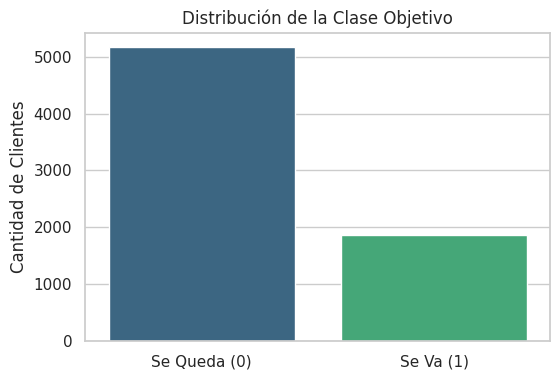

In [275]:
conteo_abandono = df_ml['Abandono_Si'].value_counts()
proporcion_abandono = df_ml['Abandono_Si'].value_counts(normalize=True) * 100

print("--- Recuento de Clientes (Basado en Abandono_Si) ---")
print(conteo_abandono)

print("\n--- Proporción (%) ---")
print(f"Se quedan (0): {proporcion_abandono[0]:.2f}%")
print(f"Se van (1):    {proporcion_abandono[1]:.2f}%")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.barplot(x=['Se Queda (0)', 'Se Va (1)'], y=conteo_abandono.values, palette='viridis')
plt.title('Distribución de la Clase Objetivo')
plt.ylabel('Cantidad de Clientes')
plt.show()

In [276]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


y = df_ml['Abandono_Si']
X = df_ml.drop(columns=['Abandono_No', 'Abandono_Si'])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("¡LOGRADO! Datos separados y escalados correctamente.")
print(f"X_train tiene {X_train_scaled.shape[0]} filas y {X_train_scaled.shape[1]} columnas.")

¡LOGRADO! Datos separados y escalados correctamente.
X_train tiene 5625 filas y 39 columnas.


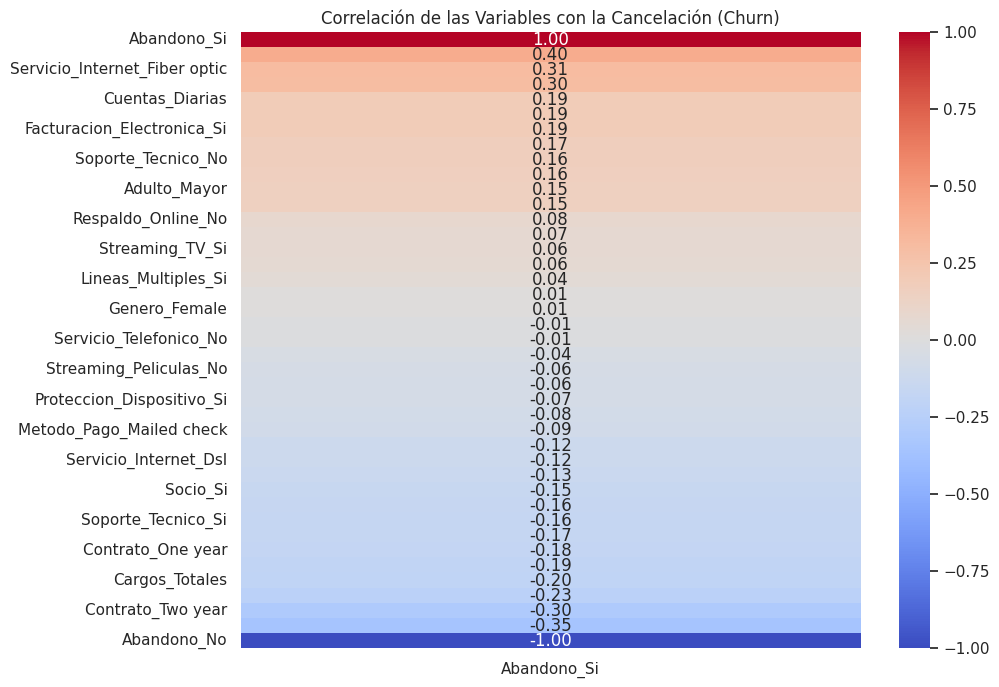

--- Top 5 Variables con más impacto POSITIVO (Aumentan la cancelación) ---
Contrato_Month-to-month          0.404565
Servicio_Internet_Fiber optic    0.307463
Metodo_Pago_Electronic check     0.301455
Cuentas_Diarias                  0.192914
Cargos_Mensuales                 0.192858
Name: Abandono_Si, dtype: float64

--- Top 5 Variables con más impacto NEGATIVO (Ayudan a que el cliente se quede) ---
Cargos_Totales         -0.199484
Servicio_Internet_No   -0.227578
Contrato_Two year      -0.301552
Meses_Permanencia      -0.354049
Abandono_No            -1.000000
Name: Abandono_Si, dtype: float64


In [277]:
correlaciones = df_ml.corr()['Abandono_Si'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(df_ml[correlaciones.index].corr()[['Abandono_Si']],
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación de las Variables con la Cancelación (Churn)')
plt.show()

print("--- Top 5 Variables con más impacto POSITIVO (Aumentan la cancelación) ---")
print(correlaciones.head(6)[1:])

print("\n--- Top 5 Variables con más impacto NEGATIVO (Ayudan a que el cliente se quede) ---")
print(correlaciones.tail(5))

/tmp/ipykernel_7787/3460100572.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos, x='Abandono', y='Meses_Permanencia', palette='magma')


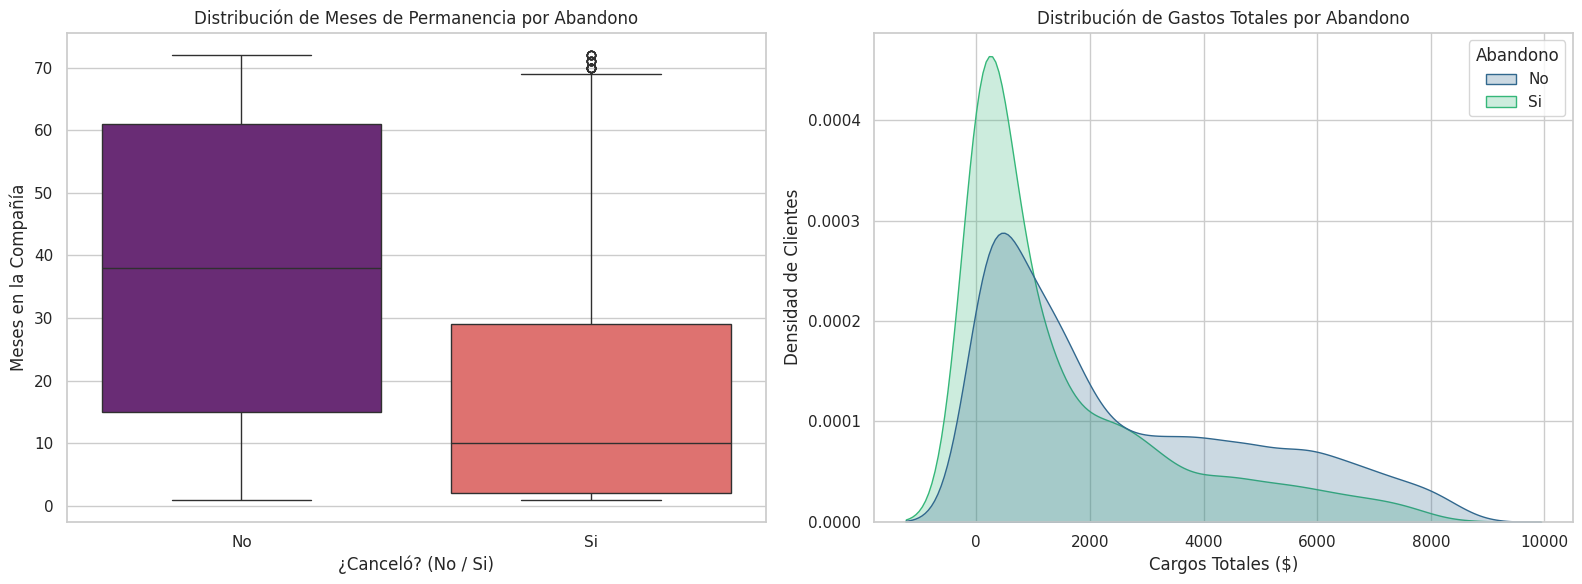

In [278]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=datos, x='Abandono', y='Meses_Permanencia', palette='magma')
plt.title('Distribución de Meses de Permanencia por Abandono')
plt.xlabel('¿Canceló? (No / Si)')
plt.ylabel('Meses en la Compañía')

plt.subplot(1, 2, 2)
sns.kdeplot(data=datos, x='Cargos_Totales', hue='Abandono', fill=True, common_norm=False, palette='viridis')
plt.title('Distribución de Gastos Totales por Abandono')
plt.xlabel('Cargos Totales ($)')
plt.ylabel('Densidad de Clientes')

plt.tight_layout()
plt.show()

In [279]:
from sklearn.model_selection import train_test_split

y = df_ml['Abandono_Si']
X = df_ml.drop(columns=['Abandono_Si', 'Abandono_No'])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("--- División de Datos Exitosa ---")
print(f"Muestras de entrenamiento (80%): {len(X_train)}")
print(f"Muestras de prueba (20%):        {len(X_test)}")

--- División de Datos Exitosa ---
Muestras de entrenamiento (80%): 5625
Muestras de prueba (20%):        1407


In [280]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train_scaled, y_train)

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

--- Métricas: Regresión Logística ---
Exactitud (Accuracy): 0.8017
Precisión:           0.6578
Recall (Sensibilidad): 0.5294
F1-Score:            0.5867

--- Métricas: Random Forest ---
Exactitud (Accuracy): 0.7910
Precisión:           0.6408
Recall (Sensibilidad): 0.4866
F1-Score:            0.5532



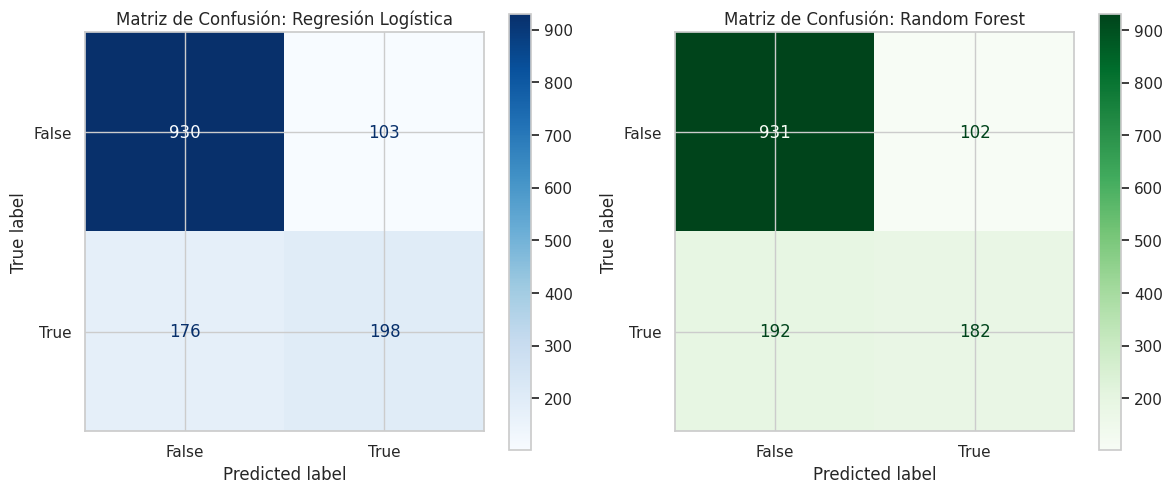

--- Verificación de Overfitting (Accuracy en Entrenamiento) ---
LR Train Accuracy: 0.8075
RF Train Accuracy: 0.9977


In [281]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluar_modelo(modelo, X, y_true, nombre_modelo):
    y_pred = modelo.predict(X)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"--- Métricas: {nombre_modelo} ---")
    print(f"Exactitud (Accuracy): {acc:.4f}")
    print(f"Precisión:           {prec:.4f}")
    print(f"Recall (Sensibilidad): {rec:.4f}")
    print(f"F1-Score:            {f1:.4f}\n")

    return y_pred

y_pred_lr = evaluar_modelo(model_lr, X_test_scaled, y_test, "Regresión Logística")

y_pred_rf = evaluar_modelo(model_rf, X_test, y_test, "Random Forest")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=ax[0], cmap='Blues')
ax[0].set_title('Matriz de Confusión: Regresión Logística')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[1], cmap='Greens')
ax[1].set_title('Matriz de Confusión: Random Forest')

plt.tight_layout()
plt.show()

print("--- Verificación de Overfitting (Accuracy en Entrenamiento) ---")
print(f"LR Train Accuracy: {model_lr.score(X_train_scaled, y_train):.4f}")
print(f"RF Train Accuracy: {model_rf.score(X_train, y_train):.4f}")

/tmp/ipykernel_7787/2211560335.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_lr, x='Coeficiente', y='Variable', ax=ax[0], palette='coolwarm')
/tmp/ipykernel_7787/2211560335.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_rf.head(15), x='Importancia', y='Variable', ax=ax[1], palette='viridis')


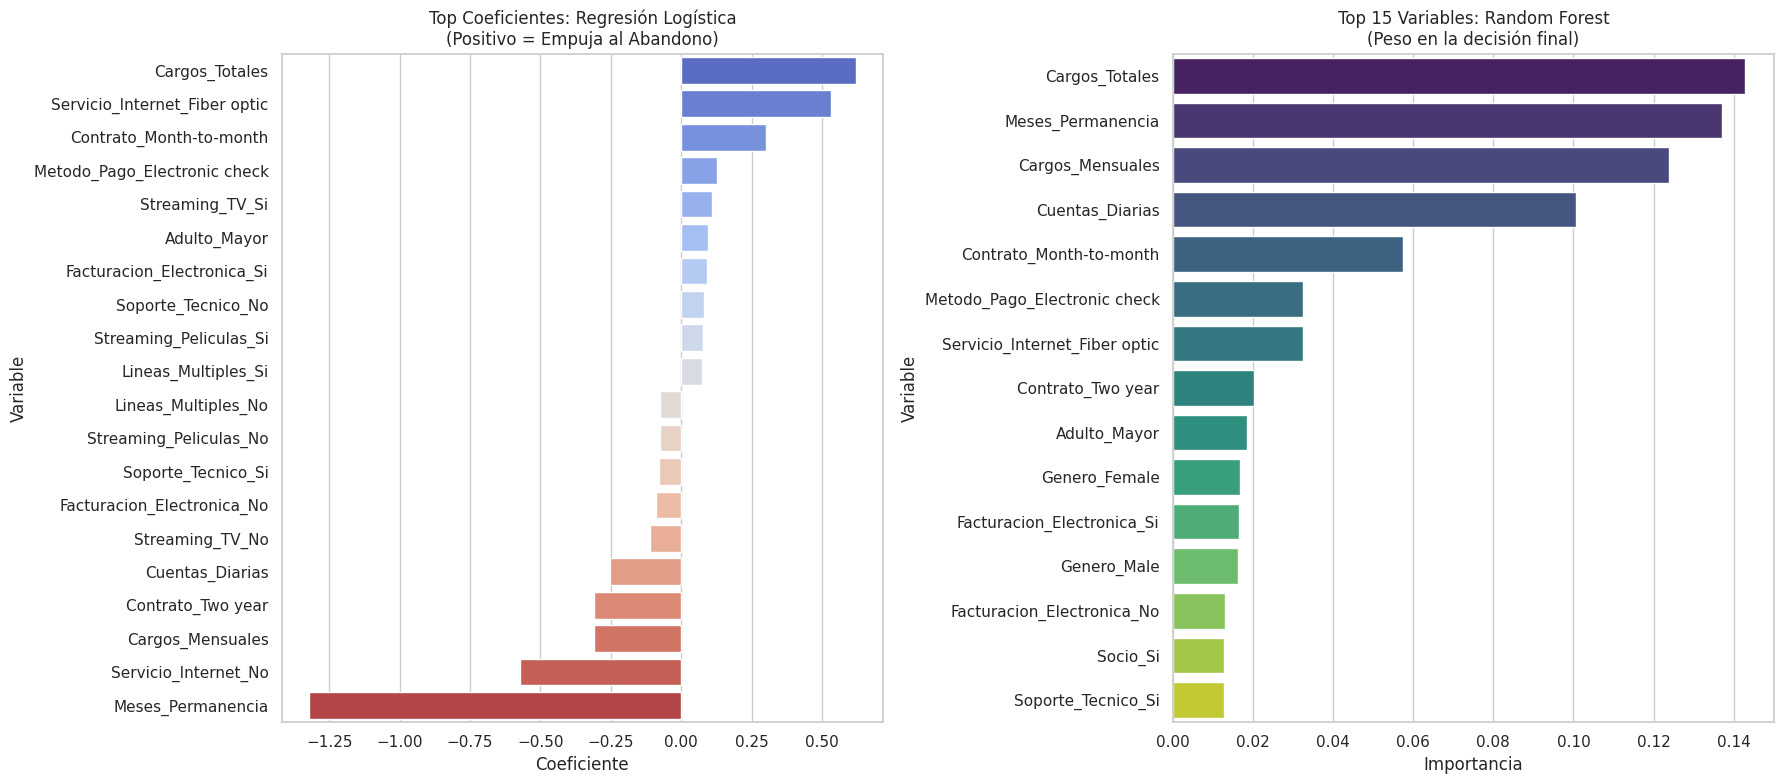

In [282]:
importancias_lr = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model_lr.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(18, 8))

top_lr = pd.concat([importancias_lr.head(10), importancias_lr.tail(10)])
sns.barplot(data=top_lr, x='Coeficiente', y='Variable', ax=ax[0], palette='coolwarm')
ax[0].set_title('Top Coeficientes: Regresión Logística\n(Positivo = Empuja al Abandono)')

sns.barplot(data=importancias_rf.head(15), x='Importancia', y='Variable', ax=ax[1], palette='viridis')
ax[1].set_title('Top 15 Variables: Random Forest\n(Peso en la decisión final)')

plt.tight_layout()
plt.show()

#Conclusión Final del Análisis: Telecom X
Después de analizar a fondo los datos de la empresa, lo primero que salta a la vista es que no todos los clientes se van por las mismas razones. Hay un patrón muy marcado: el riesgo de perder a un usuario no es constante, sino que se concentra en momentos y servicios específicos. Por ejemplo, quedó clarísimo que el contrato mes a mes es el principal "fuego" que hay que apagar. Es una relación sin compromiso que, sumada a los altos costos de la fibra óptica, crea el escenario perfecto para que el cliente se pase a la competencia apenas surja un problema.

Para tratar de predecir estos movimientos, puse a prueba dos algoritmos. Por un lado, la Regresión Logística, que después de normalizar los datos para que ninguna variable "gritara" más que otra por su tamaño, nos dio un resultado muy sólido. Logró una exactitud del 80%, y lo que es más importante, demostró ser mejor que el Random Forest a la hora de encontrar a los clientes que efectivamente se terminan yendo (el Recall). El Random Forest, aunque es una herramienta potente, se terminó "mareando" un poco con los datos de entrenamiento (hizo un poco de overfitting), por lo que para este caso me quedo con la simplicidad y efectividad de la Regresión.

Ahora, ¿qué debería hacer Telecom X con esta información? No alcanza con saber quién se va, hay que actuar. La estrategia tiene que ser quirúrgica: primero, hay que buscar la forma de "atar" a esos clientes mensuales ofreciéndoles beneficios si se pasan a un plan anual, especialmente en los primeros 12 meses, que es cuando más frágil es la relación. Además, hay que poner el ojo en el servicio de fibra óptica; los datos sugieren que algo ahí no está cerrando, ya sea por precio o por calidad, y es donde más gente estamos perdiendo. Si logramos usar este modelo para disparar alertas cuando un cliente nuevo de fibra empieza a mostrar patrones de queja, podemos salvar la cuenta antes de que sea tarde.